In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

In [8]:
# Change this path if required

df = pd.read_csv(
    "../data/raw/01 - Rebound Data.csv",
    encoding="latin1"
)

df.head()

,Sample,Droplet diameter [m],Impact velocity [m/s],Density [kg/m3],Surface Tension [N/m],Dynamic Viscosity [Pa s],Distance between adjacent laser beam passes [µm],Average depth of micro-channels [µm],Reynolds number,Weber number,Contact time [s],Rebound efficiency,Spreading coefficient,Lamella velocity [m/s]
0,D50,0.002474,0.536894,997.2375,0.07246,0.000944,50,25,1403.137456,9.813564,0.0116,0.379821,1.560187,0.630631
1,D50,0.002448,0.520219,997.2375,0.07246,0.000944,50,25,1345.333100,9.117050,0.0112,0.404025,1.561484,0.563939
2,D50,0.002458,0.525367,997.2375,0.07246,0.000944,50,25,1364.054232,9.335398,0.0114,0.390917,1.560394,0.626598
3,D50,0.002445,0.515020,997.2375,0.07246,0.000944,50,25,1330.085602,8.923632,0.0114,0.410316,1.558473,0.532609
4,D50,0.002456,0.523727,997.2375,0.07246,0.000944,50,25,1358.736271,9.269965,0.0114,0.397799,1.561609,0.595269


In [9]:
print("="*50)
print("Dataset Shape")
print("="*50)

print(df.shape)

print("\n")

print("="*50)
print("Columns")
print("="*50)

print(df.columns)

print("\n")

print("="*50)
print("Data Types")
print("="*50)

print(df.dtypes)

Dataset Shape
(1498, 14)


Columns
Index(['Sample', 'Droplet diameter [m]', 'Impact velocity [m/s]',
       'Density [kg/m3]', 'Surface Tension [N/m]', 'Dynamic Viscosity [Pa s]',
       'Distance between adjacent laser beam passes [µm]',
       'Average depth of micro-channels [µm]', 'Reynolds number',
       'Weber number', 'Contact time [s]', 'Rebound efficiency',
       'Spreading coefficient', 'Lamella velocity [m/s]'],
      dtype='str')


Data Types
Sample                        str
Droplet diameter [m]      float64
Impact velocity [m/s]     float64
Density [kg/m3]           float64
Surface Tension [N/m]     float64
                           ...   
Weber number              float64
Contact time [s]          float64
Rebound efficiency        float64
Spreading coefficient     float64
Lamella velocity [m/s]    float64
Length: 14, dtype: object


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Droplet diameter [m],1498.0,0.002384,0.000093,0.002145,0.002313,0.002357,0.002471,0.002607
Impact velocity [m/s],1498.0,1.146402,0.377078,0.484220,0.940109,1.206669,1.437428,1.711194
Density [kg/m3],1498.0,1125.001739,89.597831,997.237500,1045.036950,1152.320000,1199.551150,1231.201500
Surface Tension [N/m],1498.0,0.068763,0.002569,0.065691,0.066878,0.067635,0.071149,0.072460
Dynamic Viscosity [Pa s],1498.0,0.039926,0.057189,0.000944,0.001584,0.009137,0.037209,0.159809
...,...,...,...,...,...,...,...,...
Weber number,1498.0,56.960268,32.353737,7.955369,32.338998,58.898148,85.590829,119.133664
Contact time [s],1498.0,0.013244,0.003637,0.010000,0.011200,0.012000,0.013600,0.041400
Rebound efficiency,1498.0,0.122440,0.103901,0.004470,0.046766,0.094722,0.159028,0.466102
Spreading coefficient,1498.0,2.070036,0.431855,1.442874,1.726098,1.977099,2.360281,3.342236


In [11]:
missing = df.isnull().sum()

missing = pd.DataFrame({
    "Column":missing.index,
    "Missing Values":missing.values
})

missing

,Column,Missing Values
0,Sample,0
1,Droplet diameter [m],0
2,Impact velocity [m/s],0
3,Density [kg/m3],0
4,Surface Tension [N/m],0
...,...,...
9,Weber number,0
10,Contact time [s],0
11,Rebound efficiency,0
12,Spreading coefficient,0


In [12]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


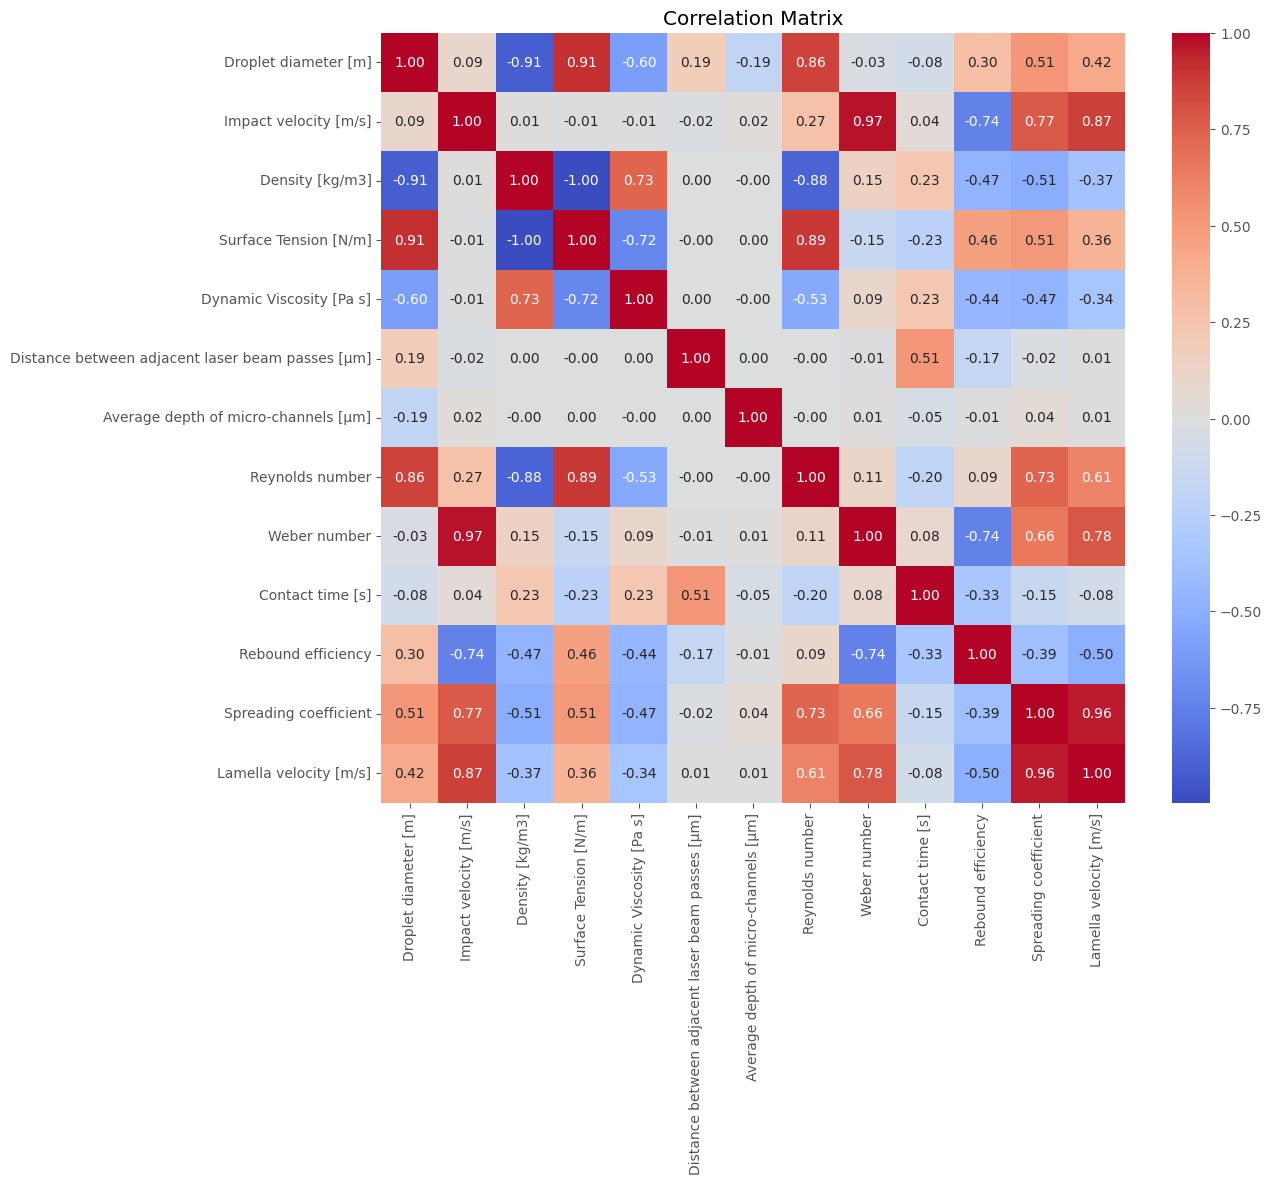

In [ ]:
#Correlation toh dikhna padega na bidu


corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

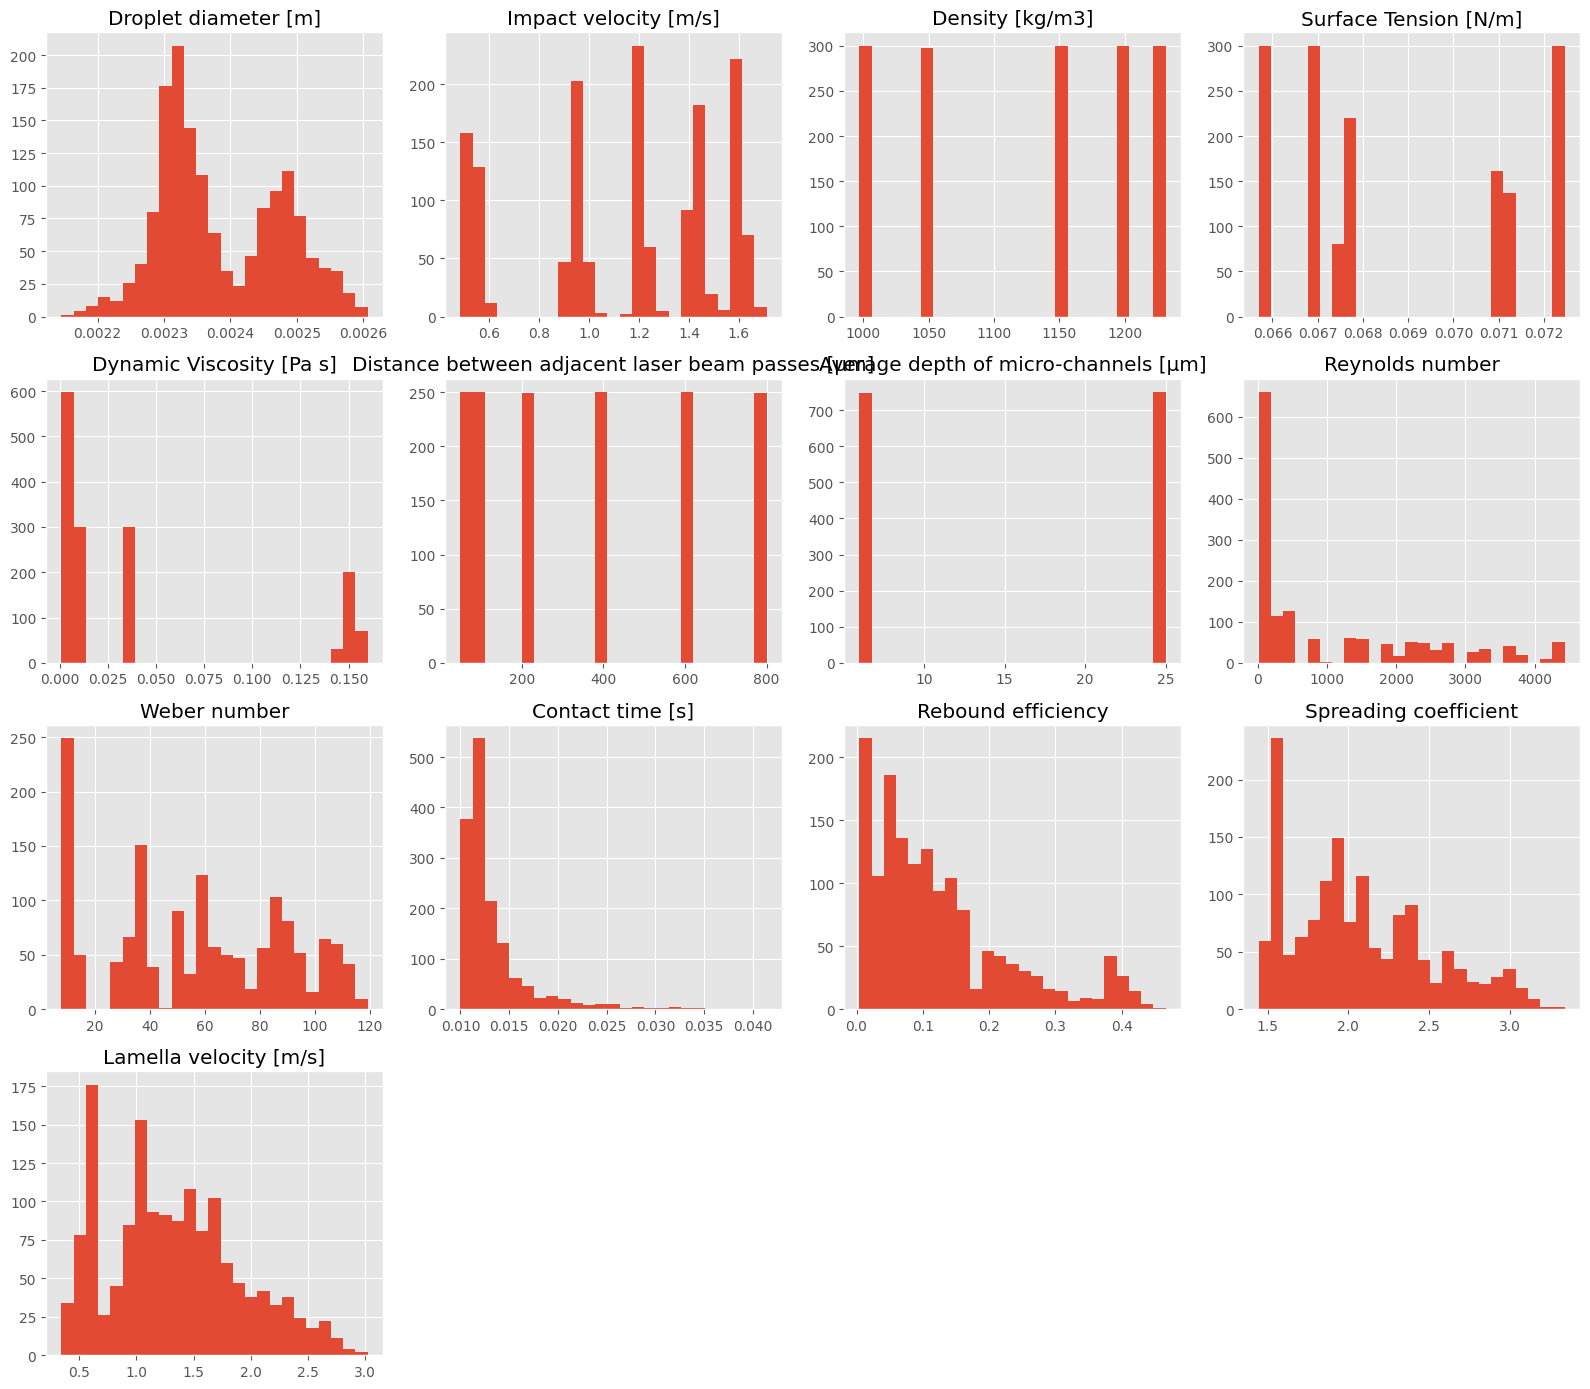

In [ ]:
#How Values are Distributed lets check with Histogram 

df.hist(
    figsize=(16,14),
    bins=25
)

plt.tight_layout()
plt.show()

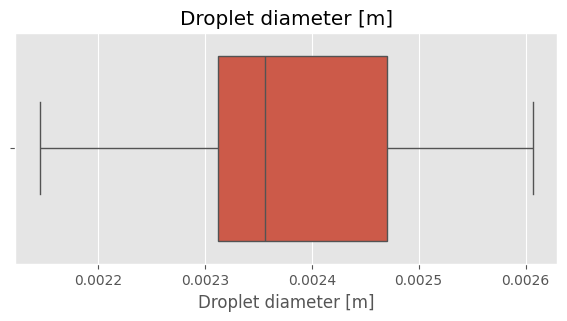

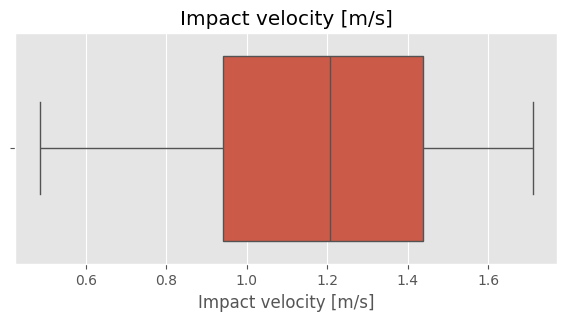

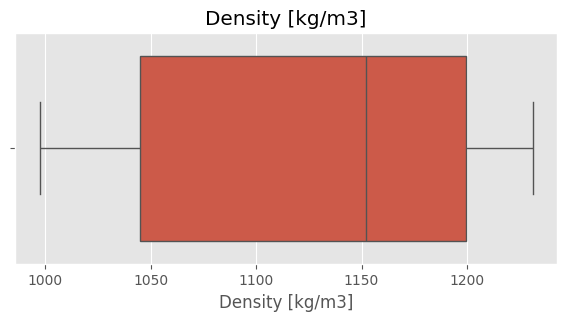

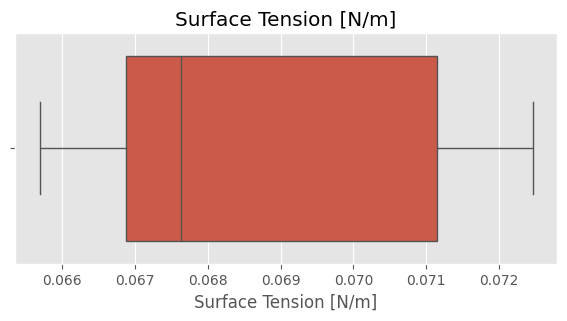

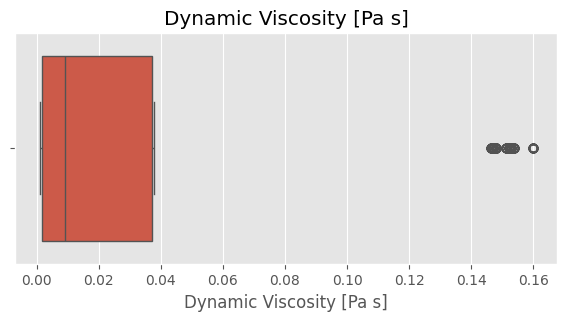

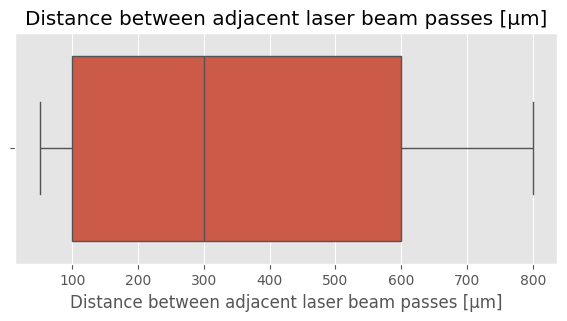

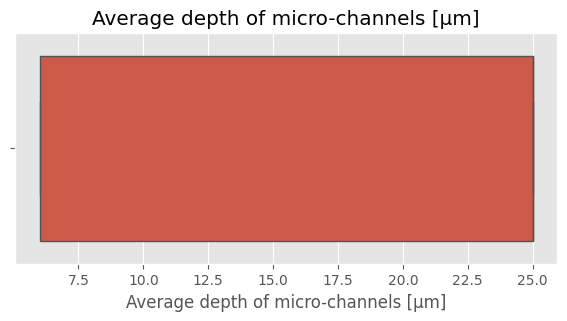

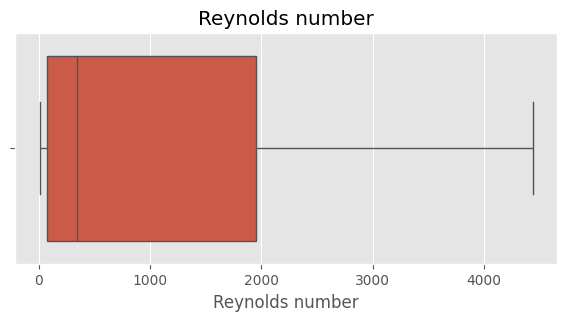

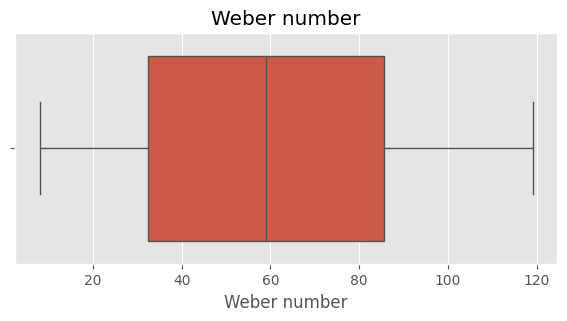

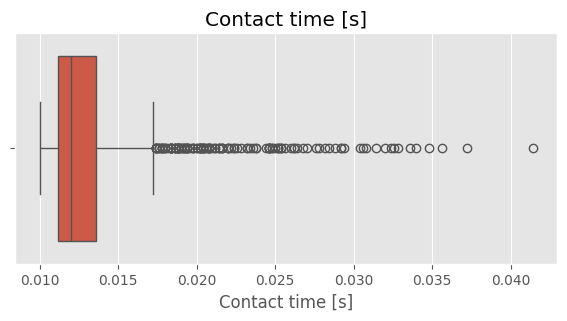

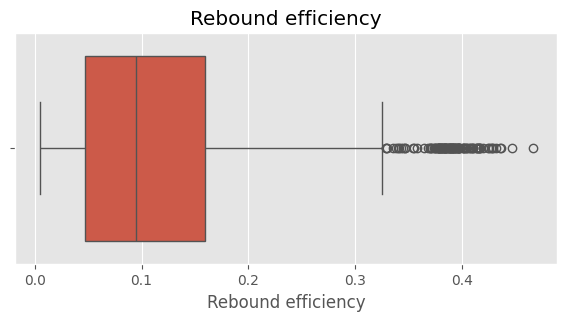

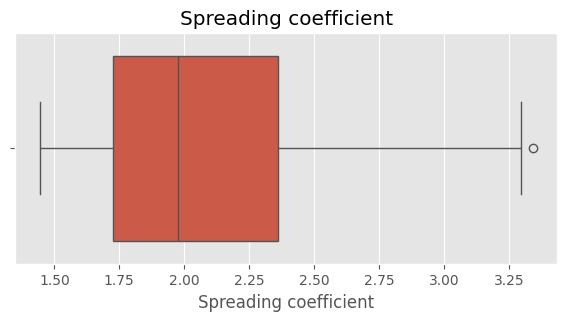

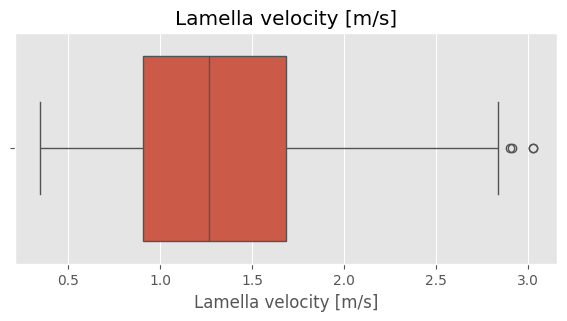

In [ ]:
#Boxplt to detect outlier

numeric = df.select_dtypes(include=np.number)

for col in numeric.columns:

    plt.figure(figsize=(7,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

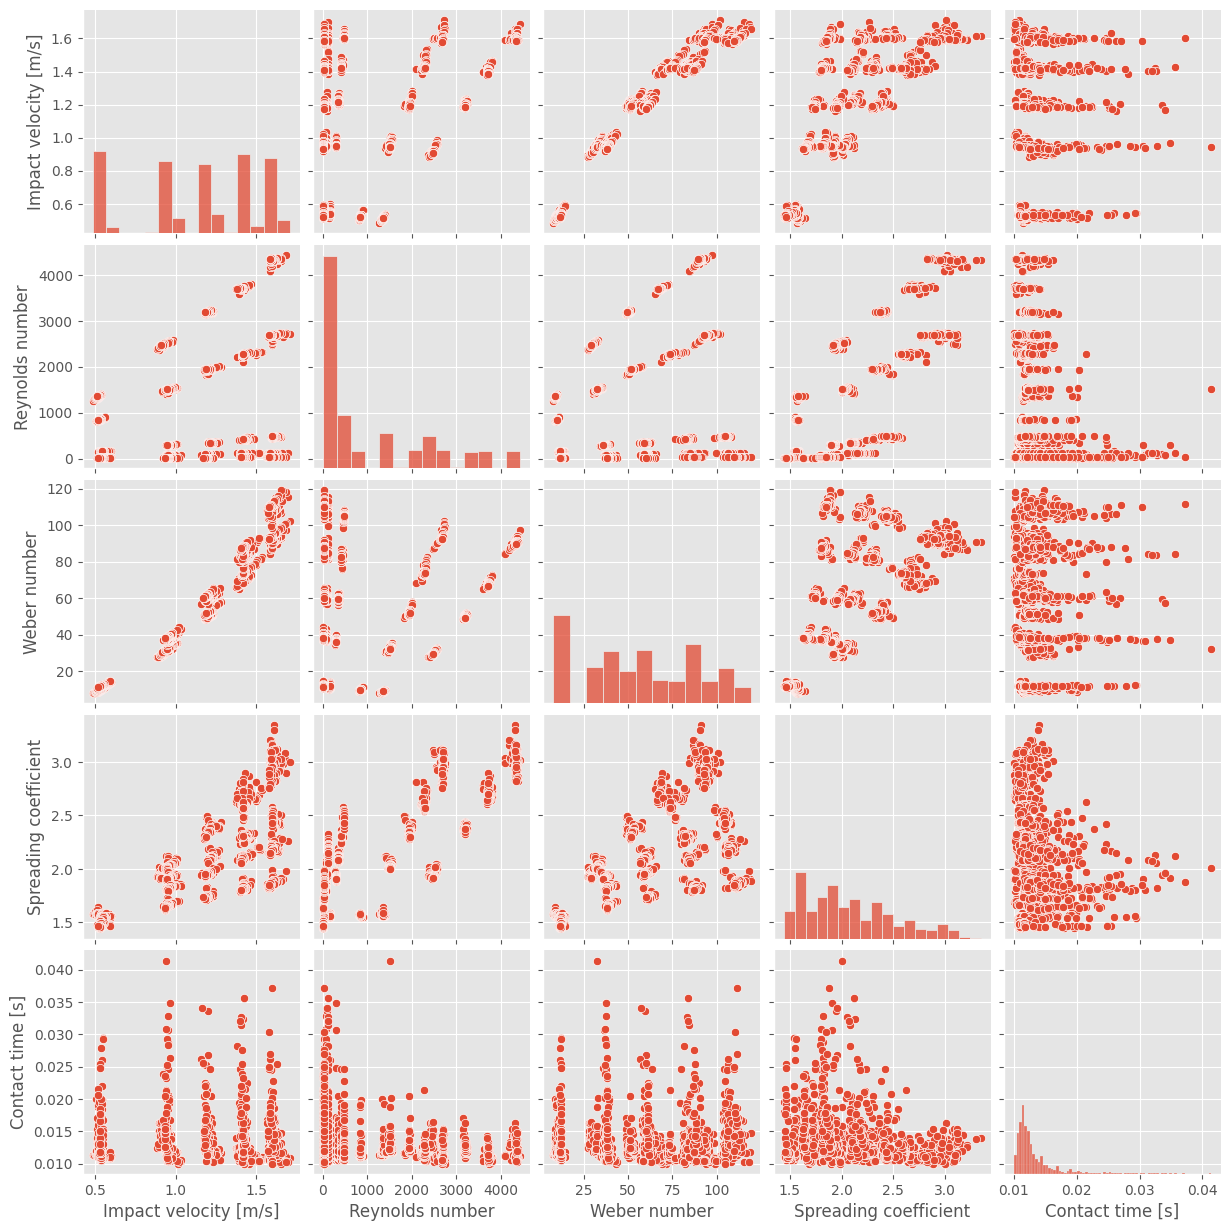

In [ ]:
# we choose these one because i think they are most relevent 

features = [

    "Impact velocity [m/s]",

    "Reynolds number",

    "Weber number",

    "Spreading coefficient",

    "Contact time [s]"

]

sns.pairplot(df[features])

plt.show()

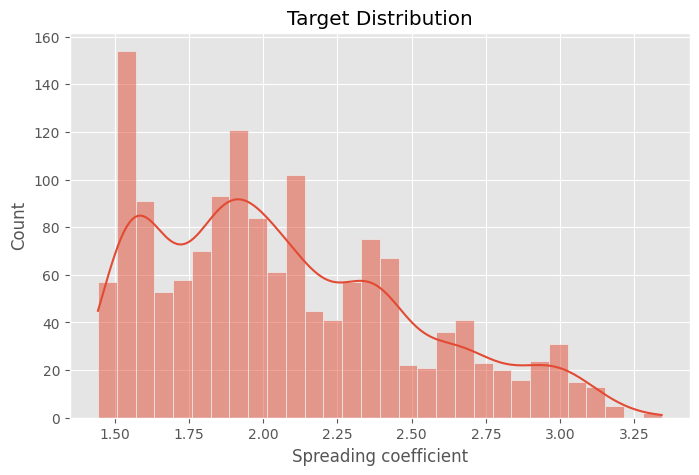

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Spreading coefficient"],
    bins=30,
    kde=True
)

plt.title("Target Distribution")

plt.show()

In [18]:
df.to_csv(
    "../data/processed/clean_dataset.csv",
    index=False
)